Testing CNN model

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd


from keras import Sequential, layers, callbacks, losses, utils, applications, Input
from keras.preprocessing import image_dataset_from_directory

2025-12-29 16:22:39.415959: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/paul/Desktop/projects/modelz/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Preprocess data and create the training and validation split 80% / 20%.

In [2]:
img_height = 224
img_width = 224

batch_size = 8

seed = 123

input_shape = [img_height,img_width, 3]
# 3 for rgb 
data_dir = "../data/tests/flower_photos"

split = 0.5

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=split,
    seed=seed,
    subset="training",
    image_size=(img_height,img_width),
    batch_size=batch_size
    )
ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=split,
    seed=seed,
    subset="validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
    )


class_names = ds_valid.class_names
num_classes = 5

Found 3670 files belonging to 5 classes.
Using 1835 files for training.


I0000 00:00:1767046961.873200  148322 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2097 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:2b:00.0, compute capability: 7.5


Found 3670 files belonging to 5 classes.
Using 1835 files for validation.


In [3]:
%%capture
for image_batch, labels_batch in ds_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_valid = ds_valid.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
#body = applications.VGG16()
#body.trainable = False

In [6]:

model_layers = [
    #body,
    layers.Conv2D(64,3, activation="relu", input_shape=input_shape),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64,3, activation="relu", input_shape=input_shape),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128,3, activation="relu", input_shape=input_shape),
    layers.MaxPooling2D(),
    
    
    # Classifier head
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
]

/home/paul/Desktop/projects/modelz/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model = Sequential(layers=model_layers)

early_stopping = callbacks.EarlyStopping(patience=5,
                                      min_delta=0.001,restore_best_weights=True)
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

Train the model

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,768,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881,669 (10.99 MB)

 Trainable params: 2,881,669 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=40,
)

Epoch 1/40


2025-12-29 16:22:43.844606: I external/local_xla/xla/service/service.cc:163] XLA service 0x72a350007710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-29 16:22:43.844624: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-12-29 16:22:43.864577: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-29 16:22:43.992765: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2025-12-29 16:22:44.356878: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

  3/230 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.2500 - loss: 157.0473

I0000 00:00:1767046968.465919  148422 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


228/230 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2409 - loss: 31.3190

2025-12-29 16:23:00.482421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-29 16:23:00.622096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2409 - loss: 31.1187

2025-12-29 16:23:02.627553: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-29 16:23:02.794936: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,109,109]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,111,111]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivatio

230/230 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.2431 - loss: 8.2834 - val_accuracy: 0.2392 - val_loss: 1.6066
Epoch 2/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.2501 - loss: 1.6034 - val_accuracy: 0.2392 - val_loss: 1.6044
Epoch 3/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.2501 - loss: 1.6005 - val_accuracy: 0.2392 - val_loss: 1.6035
Epoch 4/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.2501 - loss: 1.5989 - val_accuracy: 0.2392 - val_loss: 1.6032
Epoch 5/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.2501 - loss: 1.5980 - val_accuracy: 0.2392 - val_loss: 1.6033
Epoch 6/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.2501 - loss: 1.5975 - val_accuracy: 0.2392 - val_loss: 1.6034
Epoch 7/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.2501 - loss: 1.5973 - val_accuracy: 0.2392 - val_loss: 1.6036
Epoch 8/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.2501 - loss: 1.5971 - val_accurac

<Axes: >

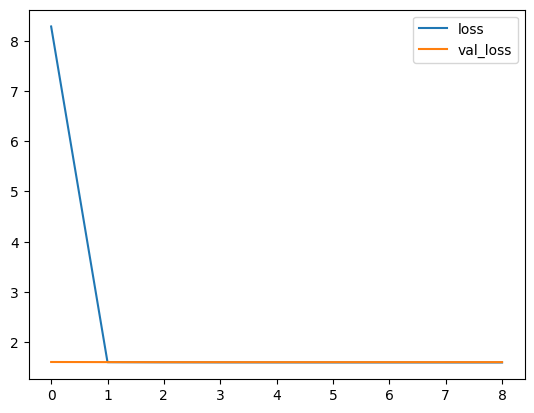

In [10]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()